# What Does the Frechet Music Distance Measure?
### A step-by-step tour of the results

**FMD sensitivity to tokenization and embedding configuration** - Warsaw
University of Technology, WIMU 2026 (M. Fereniec, B. Sedzikowski).

An FMD score is produced by a *pipeline* - input representation -> embedding
model -> Frechet formula - not by the music alone. This notebook walks through
every experiment of the study and reproduces each table directly from the
result CSVs in `results/reports/sensitivity_pivot/` (nothing is typed by
hand). It needs **no models and no GPU**; it only reads CSVs and figures.

**The two-level thesis**

1. *Attribute level:* the input representation decides which musical
   attributes FMD can perceive - velocity is detected only where it is
   encoded, and is **exactly invisible** under ABC notation.
2. *Corpus level:* style rankings are nevertheless robust across pipelines
   (Spearman rho 0.51-0.91) - "ranks styles sensibly" does **not** certify
   "sees the attribute you care about".

Full paper: [`draft.tex`](draft.tex) - methodology details:
[`docs/PAPER_FINDINGS.md`](docs/PAPER_FINDINGS.md).

## 1. Setup

Paths and display helpers. The five configurations and their properties:

| Config | Model | Input | Velocity channel? | L2-normalised? |
|:--|:--|:--|:--:|:--:|
| `MusicBERT-REMI` | MusicBERT | REMI tokens (MidiTok) | yes | no |
| `MusicBERT-TSD` | MusicBERT | TSD tokens (MidiTok) | yes | no |
| `CLaMP2-MTF` | CLaMP-2 | MIDI Text Format | yes | yes |
| `CLaMP1-ABC` | CLaMP-1 | ABC notation | **no** | yes |
| `CLaMP2-ABC` (control) | CLaMP-2 | ABC notation | **no** | yes |

`CLaMP2-ABC` is the *same-model control*: same model as `CLaMP2-MTF`, same
input as `CLaMP1-ABC` - it disentangles the representation effect from the
model effect. Datasets: MAESTRO, POP909 and four Lakh-derived genre subsets
(classical, jazz, rock, rap), 80 files each -> C(6,2) = 15 dataset pairs.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPORTS = Path("results/reports/sensitivity_pivot")
FIGURES = Path("results/plots/sensitivity_pivot/paper")

CONFIGS = ["MusicBERT-REMI", "MusicBERT-TSD", "CLaMP2-MTF", "CLaMP1-ABC", "CLaMP2-ABC"]
PERTS = ["no_velocity", "quantized_time", "constant_tempo", "all_combined"]

pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)

## 2. Why raw FMD must not be compared across models (noise floors)

Split-half FMD within one dataset should be ~0 for a stable pipeline. It is
the per-pipeline **noise floor**. MusicBERT embeddings are unnormalised
(norm ~10-20) while CLaMP embeddings live on the unit sphere, and the Frechet
formula scales with the squared embedding norm - so the floors differ by one
to two **orders of magnitude for purely geometric reasons**. This is why every
cross-configuration statement in the study uses scale-invariant statistics
(SNR, permutation/Wilcoxon tests, Spearman, CV) and never raw FMD magnitudes.

In [2]:
ss = pd.read_csv(REPORTS / "self_similarity.csv")
ss.pivot_table(index="configuration", columns="dataset", values="split_half_fmd").reindex(CONFIGS)

dataset,classical,jazz,maestro,pop909,rap,rock
configuration,,,,,,
MusicBERT-REMI,1.877,1.800,2.124,1.572,1.707,1.580
MusicBERT-TSD,1.514,1.351,2.308,2.323,1.275,1.213
CLaMP2-MTF,0.027,0.021,0.036,0.029,0.020,0.023
CLaMP1-ABC,0.054,0.076,0.054,0.058,0.075,0.077
CLaMP2-ABC,0.164,0.167,0.181,0.163,0.132,0.118


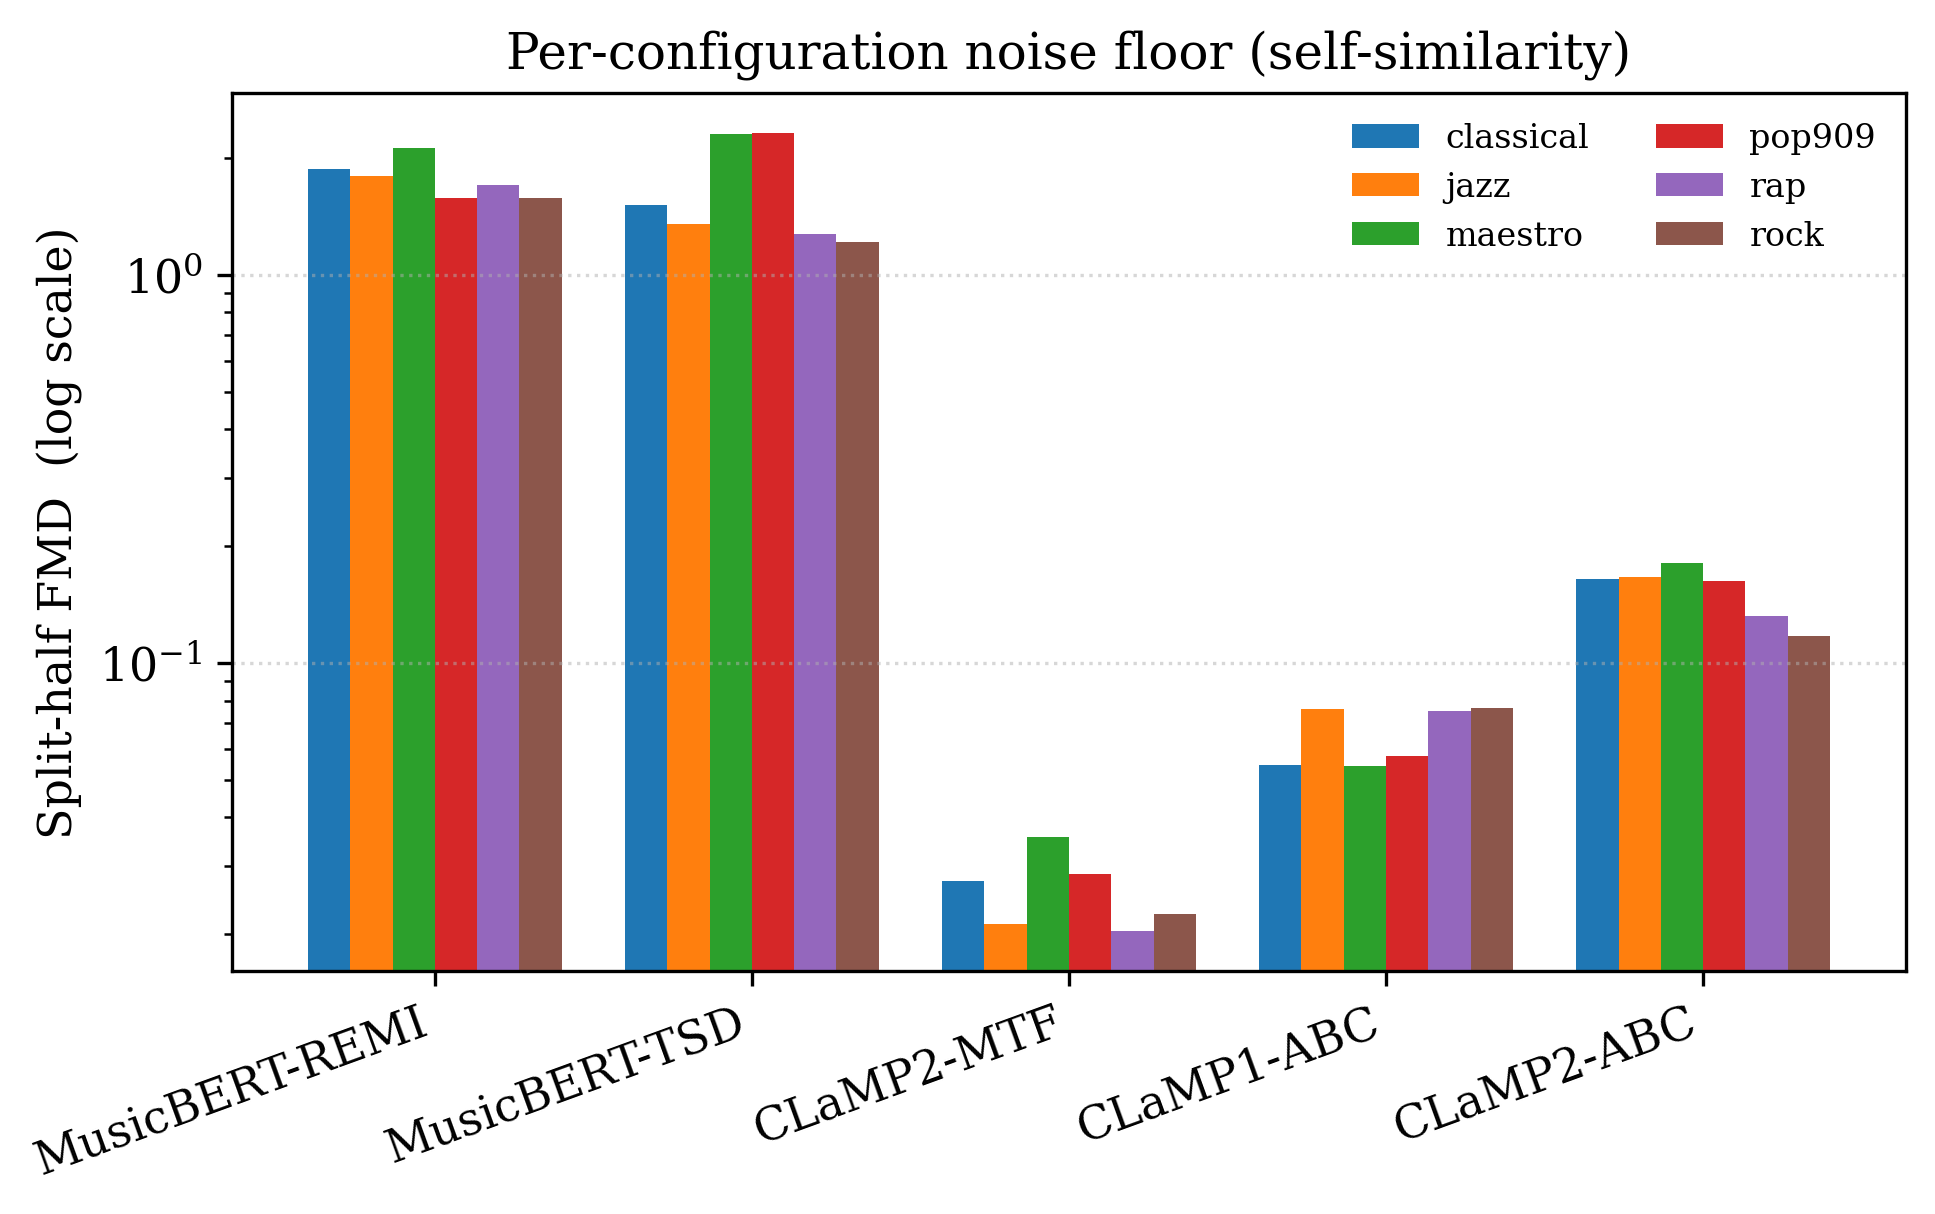

In [3]:
display(Image(filename=str(FIGURES / "fig1_noise_floor.png")))

## 3. Perturbation sensitivity (the main experiment)

We remove one expressive attribute at a time - velocity (dynamics -> 64),
microtiming (16th-note quantization), tempo (-> 120 BPM), and all combined -
and measure FMD(original, perturbed). Each effect is reported as
**SNR = FMD / noise floor** (dimensionless, comparable across pipelines) with
a two-sample **permutation test** (200 permutations).

`detected` below means SNR >= 1 **and** permutation p < 0.05.

In [4]:
def snr_table(csv_name: str) -> pd.DataFrame:
    pert = pd.read_csv(REPORTS / csv_name)
    label = lambda r: f"{r.snr:.2f}" + (" *" if r.significant else "")
    out = pert.assign(cell=pert.apply(label, axis=1)).pivot_table(
        index="perturbation", columns="configuration", values="cell", aggfunc="first"
    )
    return out.reindex(PERTS)[CONFIGS]

print("MAESTRO (primary study)  -  * = detected")
snr_table("perturbation_sensitivity.csv")

MAESTRO (primary study)  -  * = detected


configuration,MusicBERT-REMI,MusicBERT-TSD,CLaMP2-MTF,CLaMP1-ABC,CLaMP2-ABC
perturbation,,,,,
no_velocity,3.16 *,1.35 *,1.18 *,0.00,0.00
quantized_time,0.05,0.11,0.66,0.13,0.22
constant_tempo,0.06,0.14,0.13,0.04,0.20
all_combined,3.30 *,1.71 *,1.55 *,0.17,0.41


In [5]:
print("POP909 (replication)  -  * = detected")
snr_table("perturbation_sensitivity_pop909.csv")

POP909 (replication)  -  * = detected


configuration,MusicBERT-REMI,MusicBERT-TSD,CLaMP2-MTF,CLaMP1-ABC,CLaMP2-ABC
perturbation,,,,,
no_velocity,4.15 *,2.01 *,1.70 *,0.00,0.00
quantized_time,0.00,0.00,0.50,0.00,0.00
constant_tempo,0.01,0.28,0.16,0.02,0.12
all_combined,4.23 *,2.43 *,2.07 *,0.02,0.12


**What the tables show**

- **Velocity is the only attribute detected above the noise floor, and only
  where it is represented**: REMI (SNR 3.16 / 4.15), TSD (1.35 / 2.01) and
  MTF (1.18 / 1.70) on MAESTRO / POP909, all permutation-significant.
- Under both ABC pipelines the velocity-flattened corpus renders to
  **character-identical ABC**, so FMD = 0.0000 *exactly* - the blindness is
  structural, not statistical. The `CLaMP2-ABC` column is the causal control:
  same model as `CLaMP2-MTF`, only the representation differs.
- Microtiming and tempo stay below the detection floor everywhere; the
  *combined* perturbation simply tracks velocity.
- Built-in sanity check: POP909 is already grid-quantized, so quantization is
  a no-op there and the token pipelines report FMD = 0 - the protocol reports
  nothing where nothing changed.

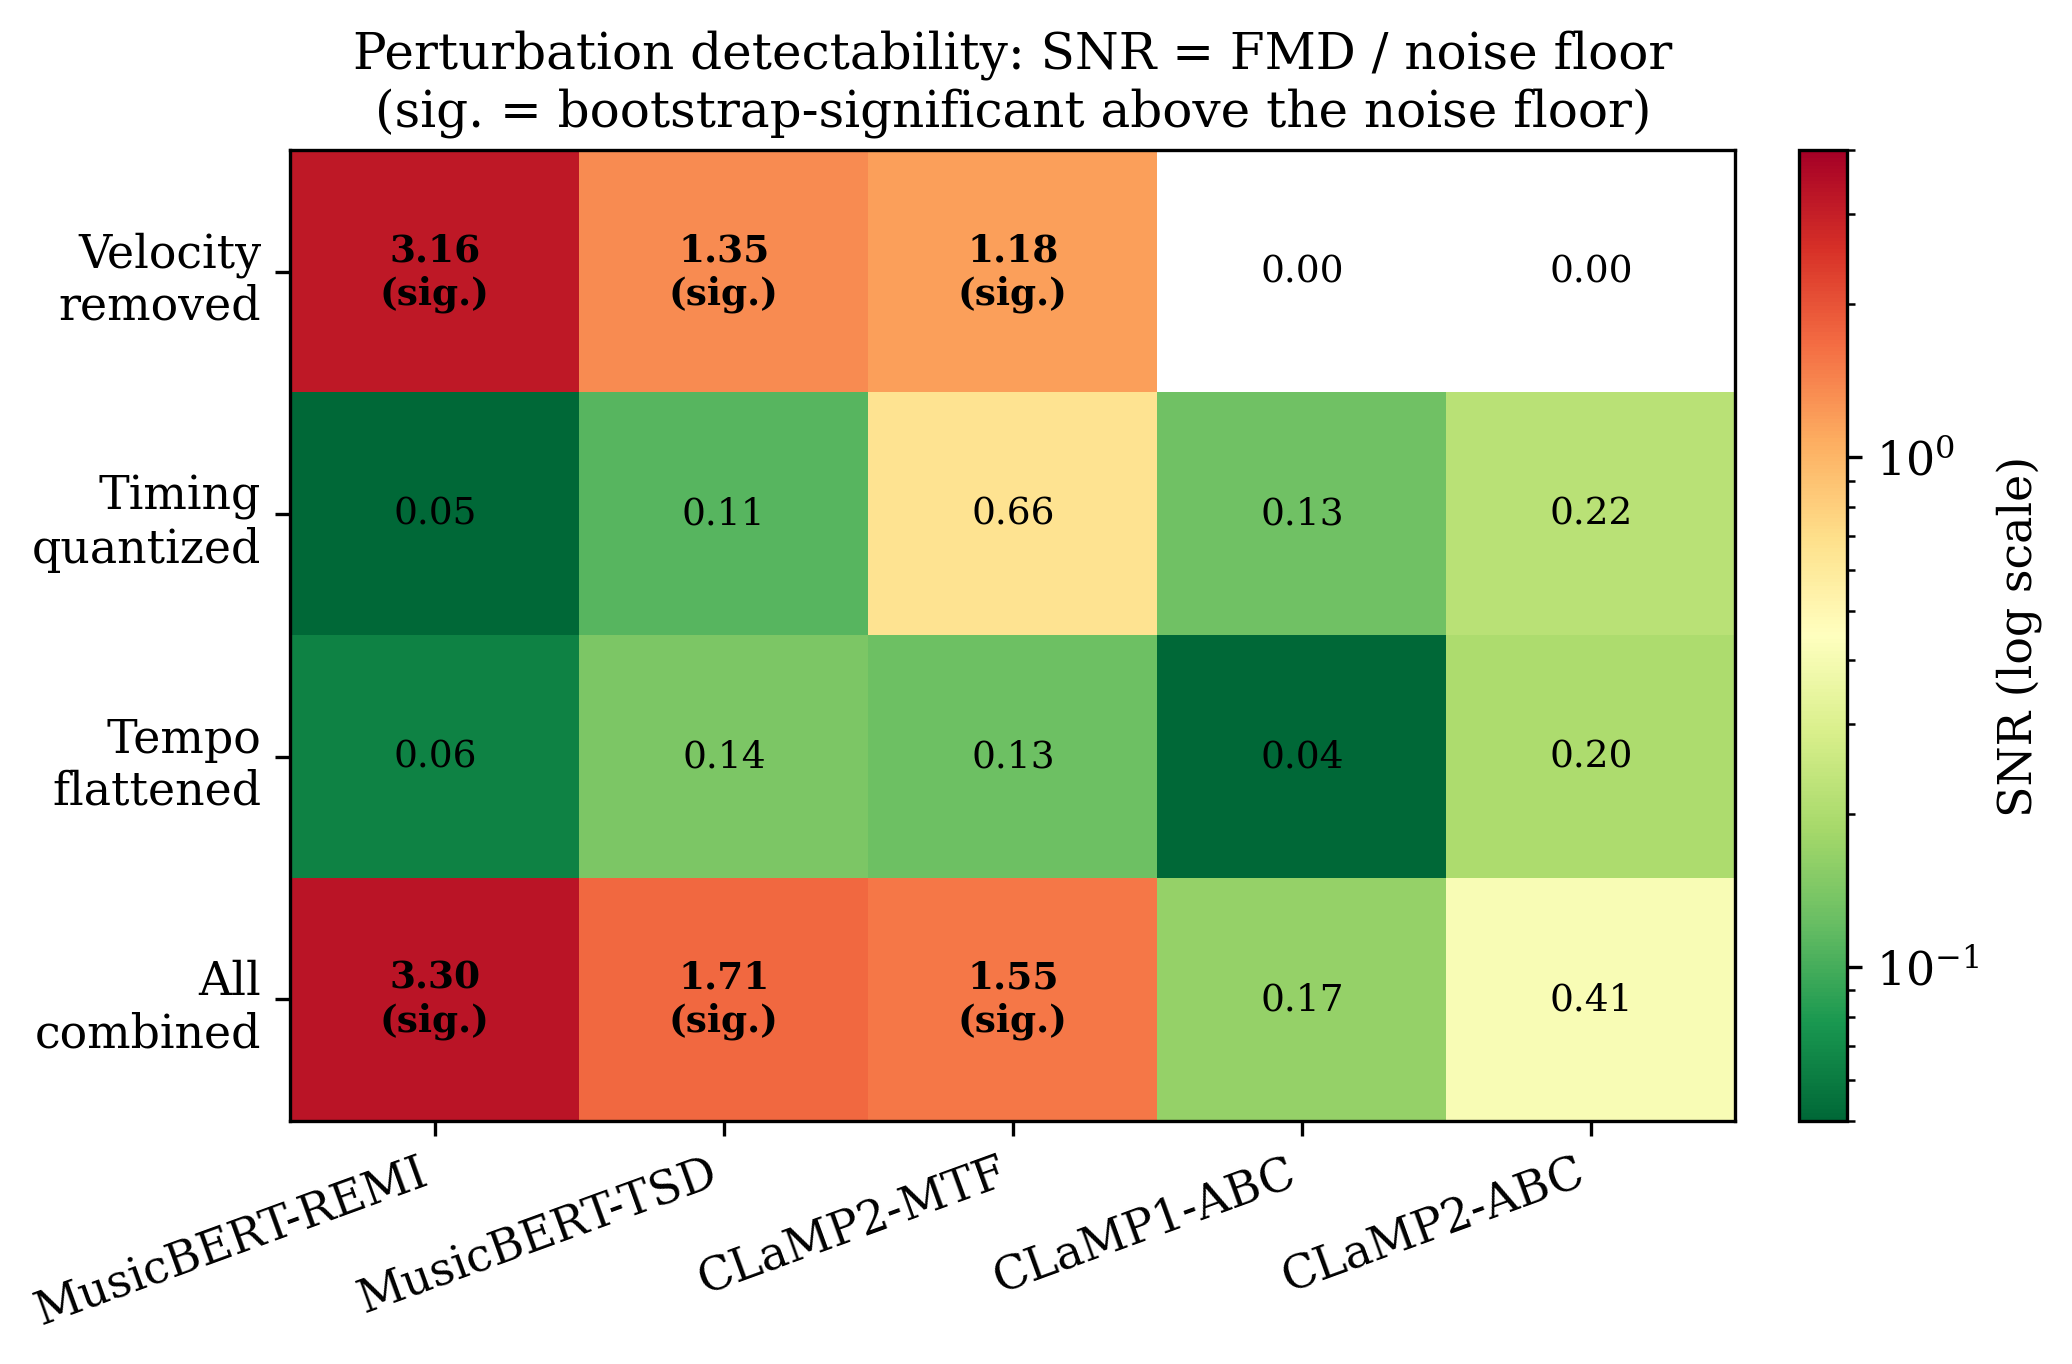

In [6]:
display(Image(filename=str(FIGURES / "fig2_snr_heatmap.png")))

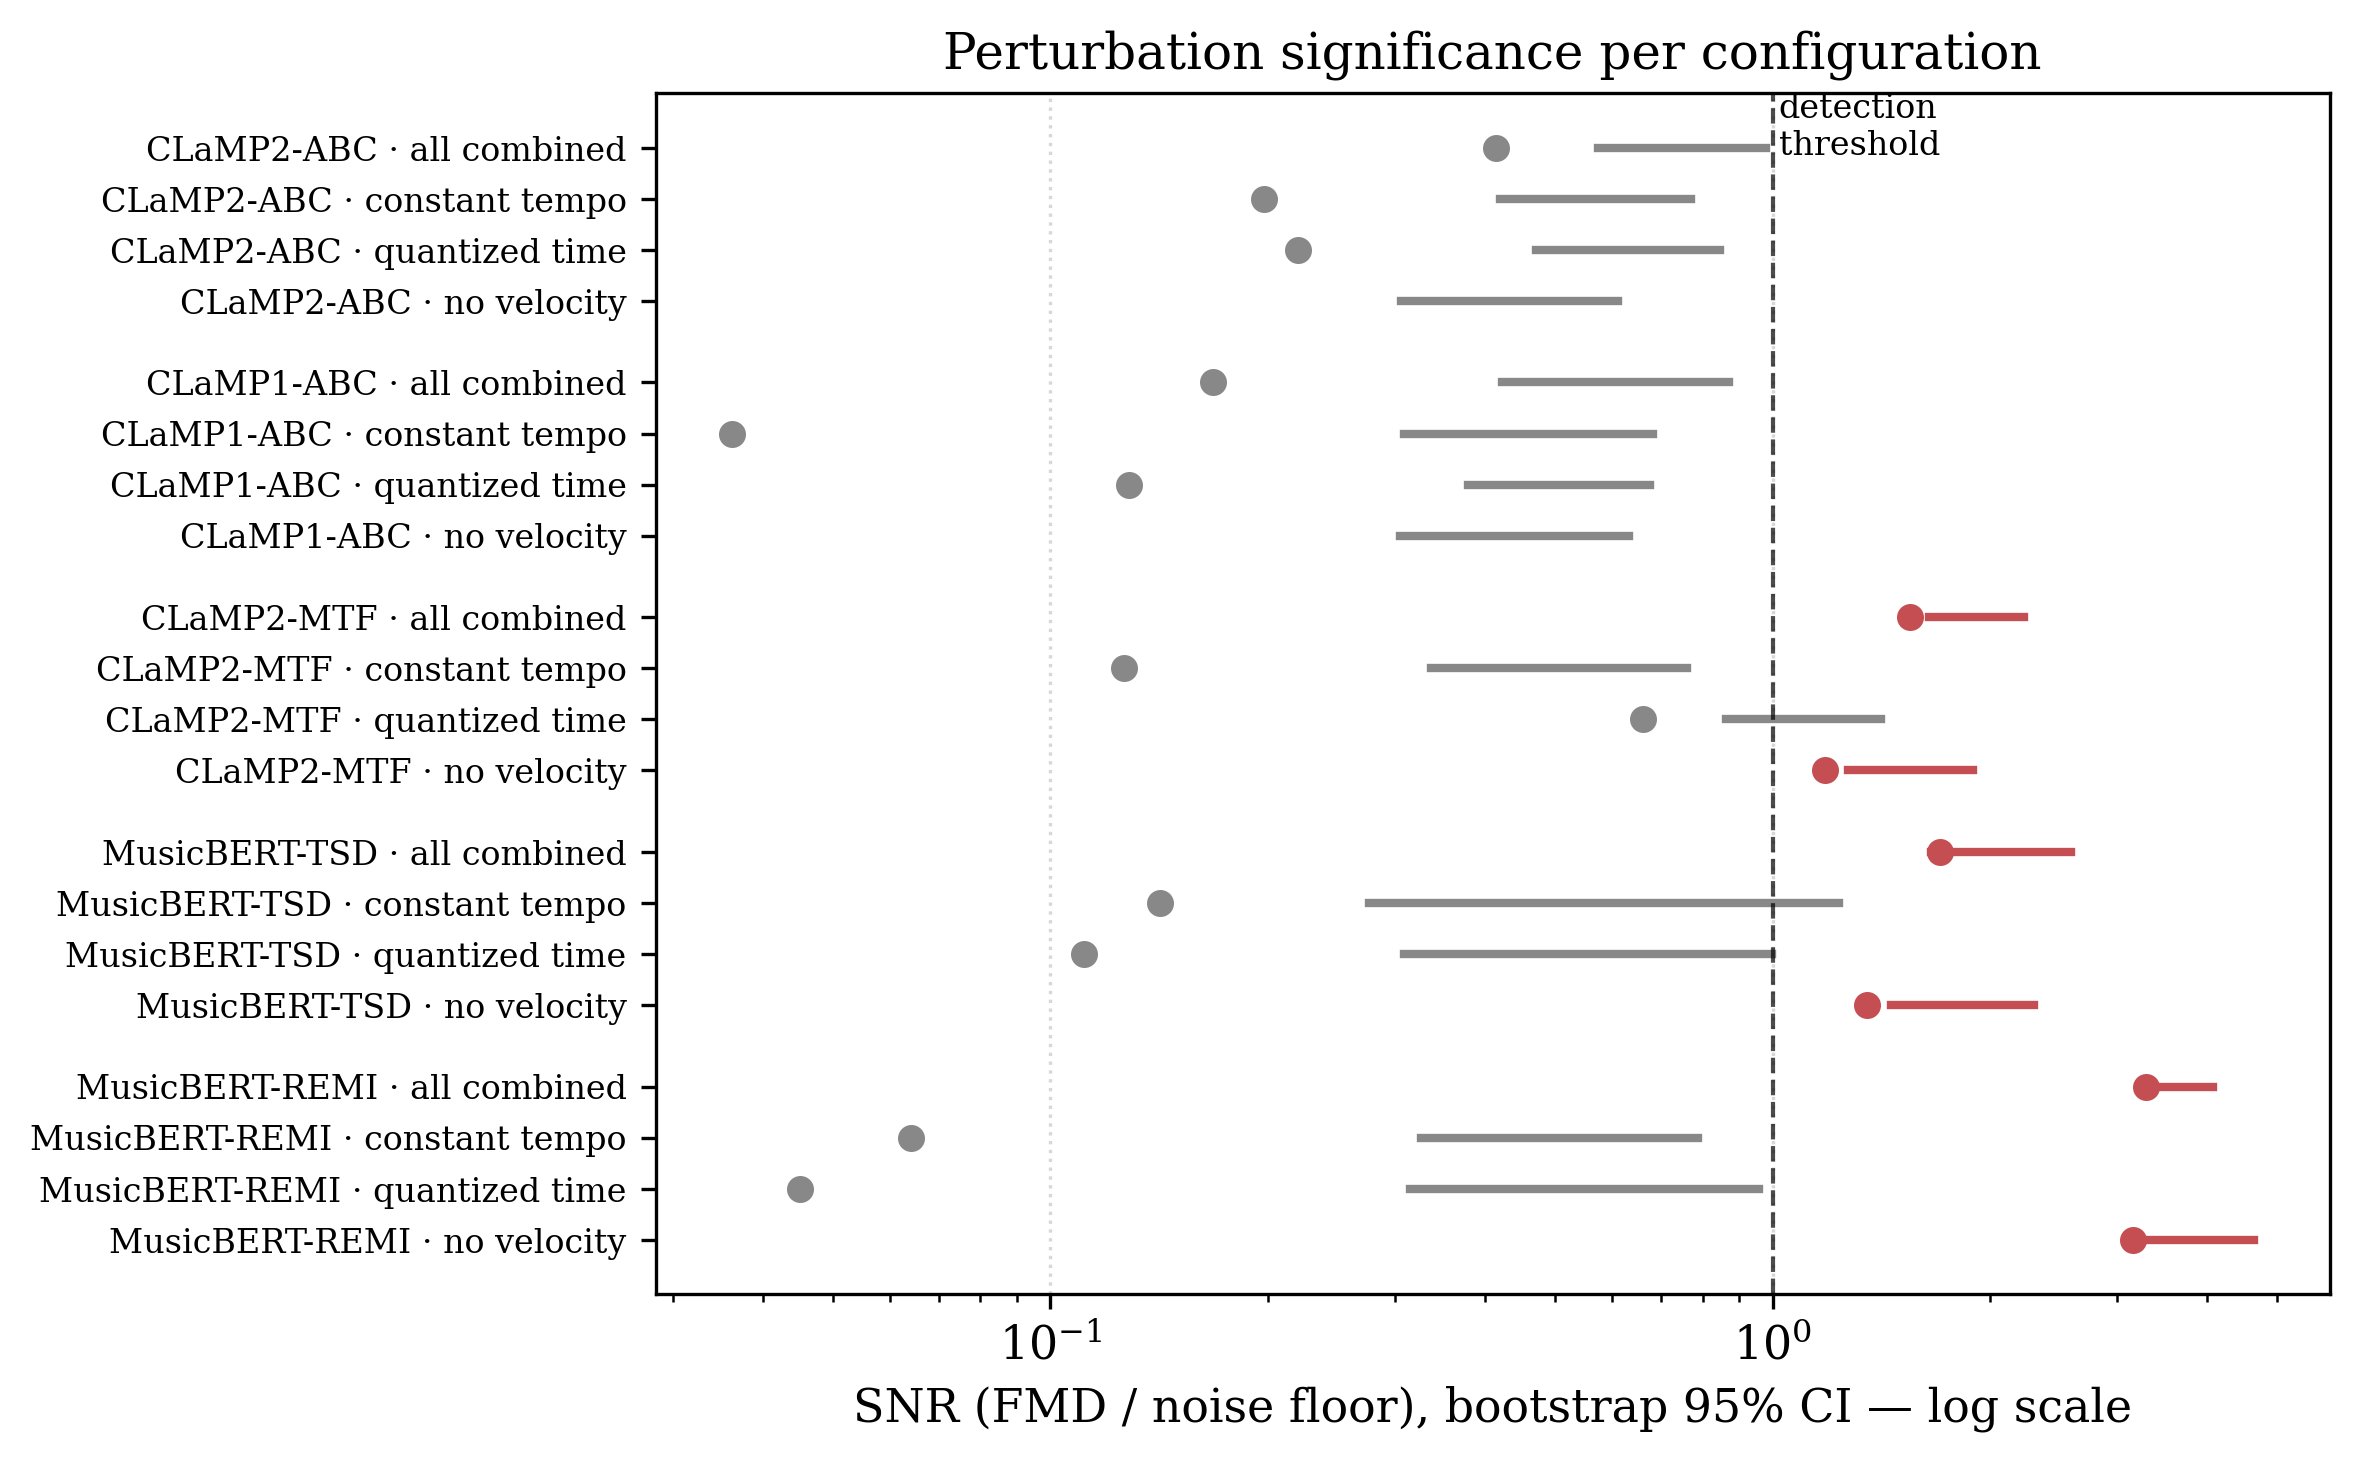

In [7]:
display(Image(filename=str(FIGURES / "fig4_perturbation_significance.png")))

## 4. Per-file paired analysis (Wilcoxon + retest noise floor)

FMD is a distribution-level statistic estimated at n=80 << d=768. To show the
signal is not a distribution-fitting artifact, we also measure the **cosine
shift of every individual file** between its original and perturbed
embedding, and compare it against a **retest** condition - the same
unperturbed file encoded twice. The retest distance is the per-file
encoding-noise floor (zero for every pipeline: all conversions are
deterministic). Contrasts are one-sided Wilcoxon signed-rank tests with Holm
correction.

> The retest check earns its keep: an earlier iteration unknowingly embedded
> `music21` object reprs instead of ABC (music21 has no ABC export - its
> `write('abc')` silently emits the repr). Re-encodings of the same file came
> out near-orthogonal, and the retest caught it immediately. We replaced the
> conversion with a deterministic MIDI->ABC renderer. **Recommendation: build
> a retest into any embedding pipeline - it is nearly free.**

In [8]:
tests = pd.concat([
    pd.read_csv(REPORTS / "paired_file_tests.csv"),
    pd.read_csv(REPORTS / "paired_file_tests_pop909.csv"),
])
velocity = tests[tests.perturbation == "no_velocity"][
    ["dataset", "contrast", "configuration", "n_files", "median_shift", "p_holm", "significant"]
]
velocity.sort_values(["contrast", "dataset", "configuration"]).reset_index(drop=True)

,dataset,contrast,configuration,n_files,median_shift,p_holm,significant
0,maestro,control_mtf_gt_abc_velocity_excess,CLaMP2-MTF_vs_CLaMP2-ABC,80,0.027,1.020e-13,True
1,pop909,control_mtf_gt_abc_velocity_excess,CLaMP2-MTF_vs_CLaMP2-ABC,80,0.039,1.020e-13,True
2,maestro,exceeds_retest_noise,CLaMP1-ABC,80,0.000,1.000e+00,False
3,maestro,exceeds_retest_noise,CLaMP2-ABC,80,0.000,1.000e+00,False
4,maestro,exceeds_retest_noise,CLaMP2-MTF,80,0.027,1.020e-13,True
5,maestro,exceeds_retest_noise,MusicBERT-REMI,80,0.005,1.020e-13,True
6,maestro,exceeds_retest_noise,MusicBERT-TSD,80,0.002,1.020e-13,True
7,pop909,exceeds_retest_noise,CLaMP1-ABC,80,0.000,1.000e+00,False
8,pop909,exceeds_retest_noise,CLaMP2-ABC,80,0.000,1.000e+00,False
9,pop909,exceeds_retest_noise,CLaMP2-MTF,80,0.039,1.020e-13,True


**Reading:** velocity flattening moves the embedding of essentially *every
individual file* in the velocity-bearing pipelines (Holm-adjusted
p ~ 1e-13 on both corpora) and **exactly zero files** under ABC. The
same-model control contrast (`CLaMP2-MTF` vs `CLaMP2-ABC`, within one
embedding space) is significant at p ~ 1e-13 on both corpora.

Bonus dissociation: on MAESTRO, MTF quantization shifts are per-file
significant even though the corpus-level SNR stays below 1 - the file-level
view is *more* sensitive than FMD itself.

## 5. Corpus-level rankings are robust across pipelines

Each configuration ranks the 15 dataset pairs by FMD; Spearman rho between
configurations is scale-invariant, so it is a sound cross-pipeline
comparison. Despite radically different attribute sensitivity, **9 of 10
configuration pairs agree significantly** (rho 0.51-0.91) - the strongest
agreement is MTF vs ABC (rho = 0.907), two pipelines in incomparable spaces,
one of which cannot see dynamics at all. The only non-significant pair is
REMI vs TSD: the tokenizer perturbs the ranking more than swapping
model+representation does.

In [9]:
sp = pd.read_csv(REPORTS / "spearman_ranking_agreement.csv")
sp[["config_a", "config_b", "spearman_tau", "p_value"]].sort_values(
    "spearman_tau", ascending=False
).reset_index(drop=True)

,config_a,config_b,spearman_tau,p_value
0,CLaMP2-MTF,CLaMP1-ABC,0.907,3.063e-06
1,CLaMP1-ABC,CLaMP2-ABC,0.907,3.063e-06
2,MusicBERT-REMI,CLaMP1-ABC,0.868,2.752e-05
3,CLaMP2-MTF,CLaMP2-ABC,0.836,1.044e-04
4,MusicBERT-REMI,CLaMP2-MTF,0.825,1.532e-04
5,MusicBERT-REMI,CLaMP2-ABC,0.811,2.460e-04
6,MusicBERT-TSD,CLaMP1-ABC,0.621,1.340e-02
7,MusicBERT-TSD,CLaMP2-MTF,0.525,4.448e-02
8,MusicBERT-TSD,CLaMP2-ABC,0.514,4.984e-02
9,MusicBERT-REMI,MusicBERT-TSD,0.436,1.045e-01


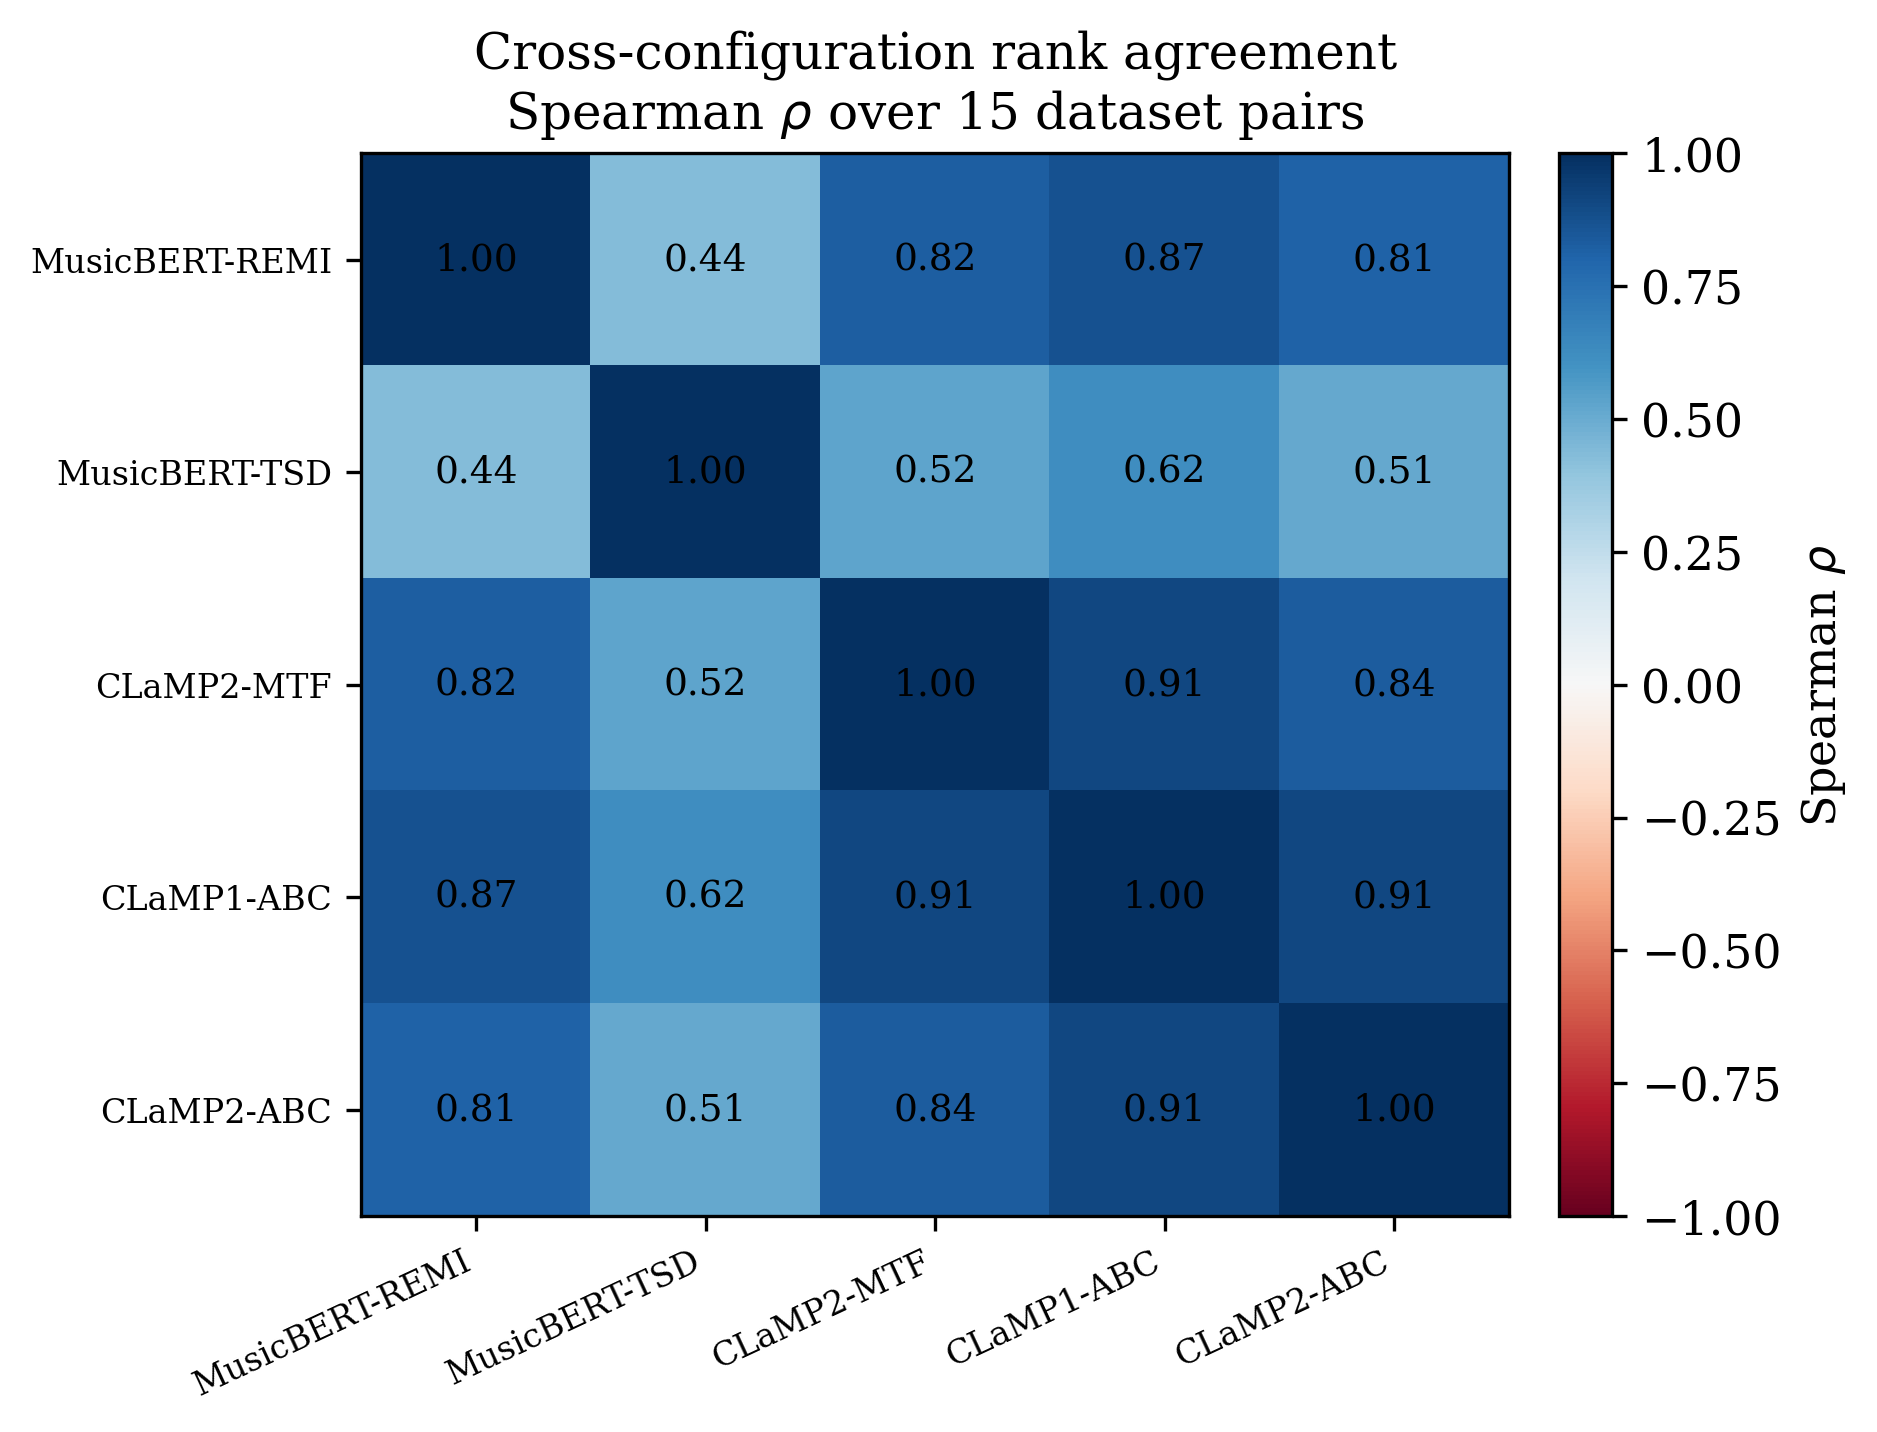

In [10]:
display(Image(filename=str(FIGURES / "fig5_spearman_heatmap.png")))

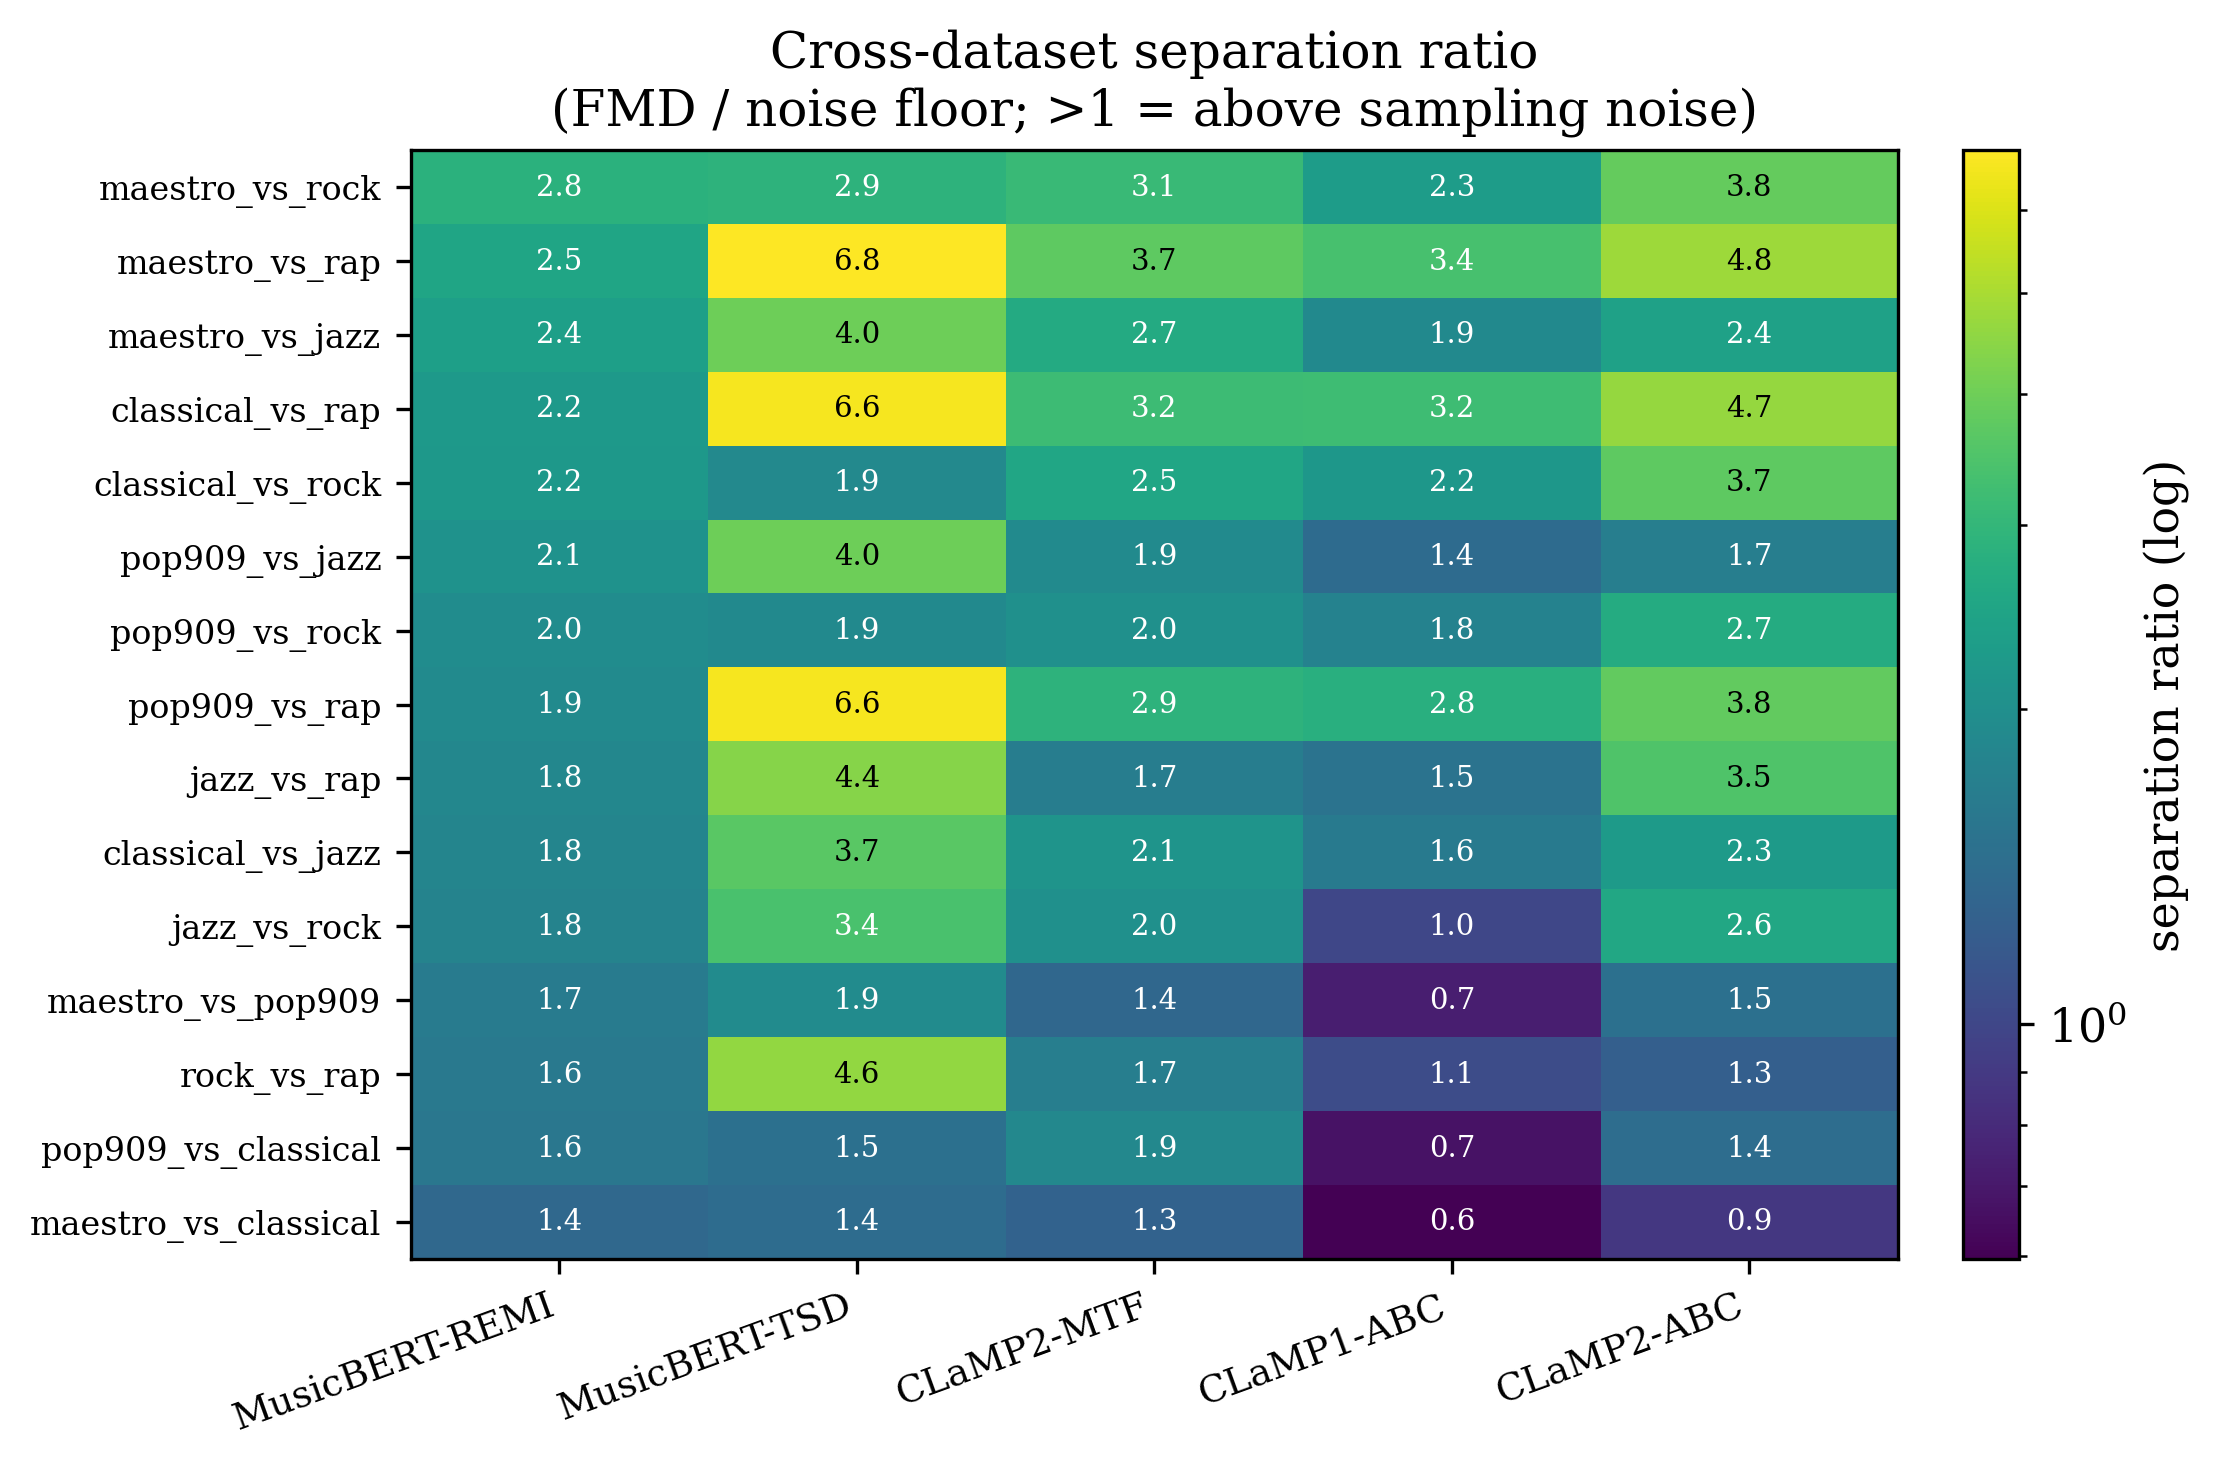

In [11]:
display(Image(filename=str(FIGURES / "fig6_cross_dataset_sep.png")))

## 6. Bootstrap stability

50 bootstrap resamples of the MAESTRO-POP909 distance. The coefficient of
variation (CV) is scale-invariant: all five pipelines are comparably stable
(8-20%), with the ABC pipelines the most stable. The mean column is **not**
comparable across the normalisation boundary.

In [12]:
boot = pd.read_csv(REPORTS / "bootstrap_stability.csv")
boot.assign(cv_pct=(boot.cv * 100).round(1))[
    ["configuration", "fmd_mean", "fmd_ci_lower", "fmd_ci_upper", "cv_pct"]
].set_index("configuration").reindex(CONFIGS)

,fmd_mean,fmd_ci_lower,fmd_ci_upper,cv_pct
configuration,,,,
MusicBERT-REMI,3.511,2.662,4.637,15.1
MusicBERT-TSD,3.924,2.742,5.473,20.2
CLaMP2-MTF,0.048,0.039,0.060,14.0
CLaMP1-ABC,0.068,0.059,0.080,8.0
CLaMP2-ABC,0.277,0.243,0.320,8.0


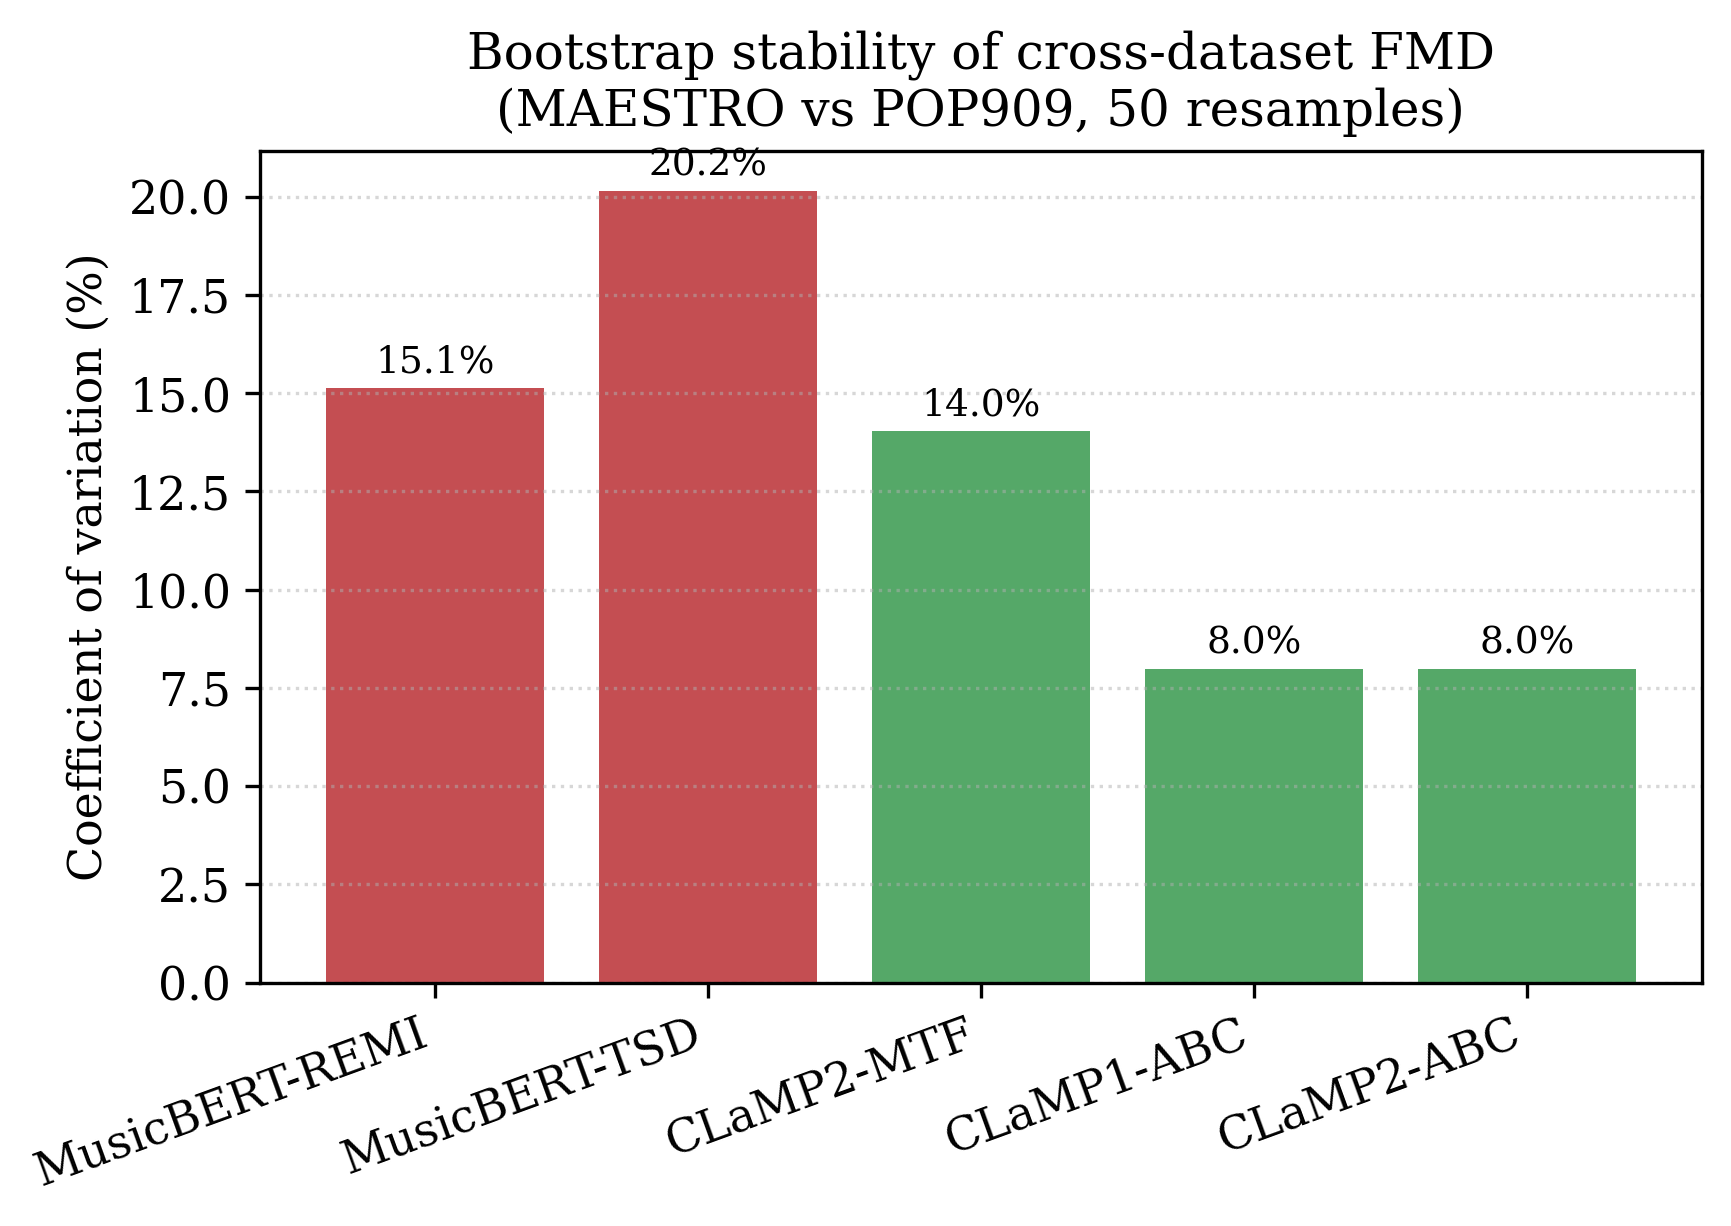

In [13]:
display(Image(filename=str(FIGURES / "fig3_bootstrap_cv.png")))

## 7. Conclusions and practitioner guidance

| # | Finding | Evidence |
|:-:|:--|:--|
| 1 | Input representation sets a hard, **causal** ceiling on what FMD detects | velocity SNR 1.2-4.2 (p <= 0.02) in REMI/TSD/MTF vs **exactly 0** in ABC; same-model control switches it off; per-file p ~ 1e-13; replicated on POP909 |
| 2 | Corpus-level style rankings are robust across pipelines | 9/10 pairs significant, rho 0.51-0.91 (MTF-ABC 0.907) |
| 3 | The tokenizer alone reshapes sensitivity | REMI vs TSD velocity SNR 3.16 vs 1.35; REMI-TSD is the only n.s. ranking pair |
| 4 | Raw FMD is not cross-model comparable | noise floors differ by orders of magnitude from embedding geometry alone |

**If you evaluate music generation with FMD:**

- to judge *dynamics/expression*, use a velocity-bearing representation
  (REMI/TSD tokens, MTF) - never ABC;
- ABC-based FMD is fine for *score-like stylistic* comparison and ranks
  styles consistently with the other pipelines;
- never compare raw FMD numbers across embedding models - use SNR, rank
  agreement, or CV;
- treat microtiming/tempo effects with suspicion at n ~ 80;
- **audit your pipeline with a per-file retest** (encode one file twice) -
  it is nearly free and catches silent conversion failures.

**Reproduce everything**

```bash
python scripts/run_full_study.py            # full study (checkpointed)
python scripts/generate_draft_figures.py    # paper figures from CSVs
python scripts/generate_draft_tables.py     # paper tables from CSVs
pdflatex draft.tex                          # the paper (run twice)
```